# 📝 **Entre Opiniones y Estrellas: El Caso Yelp**

Yelp es una plataforma reconocida a nivel mundial que permite a los usuarios calificar y dejar reseñas sobre negocios locales, como restaurantes, bares, peluquerías, entre otros.

En este trabajo, tendrás la oportunidad de analizar un **dataset real de reviews generadas por usuarios**, recopiladas durante varios meses.

El equipo de **Diseño de Producto de Yelp** ha compartido este conjunto de datos con el área de **Data Science** para obtener información valiosa que contribuya a mejorar la experiencia del usuario y optimizar las decisiones estratégicas.

---

## 🎯 Desafío

Tu misión será **extraer valor a partir de los datos conversacionales** disponibles. ¿Qué información relevante puedes descubrir sobre los negocios analizados?

- ¿Qué sienten los clientes?
- ¿Qué aspectos destacan positiva o negativamente?
- ¿Qué negocios generan mayor satisfacción o descontento?

Este proyecto es una oportunidad ideal para aplicar técnicas de **Procesamiento de Lenguaje Natural (NLP)** y aportar una mirada analítica sobre la voz del cliente.

Prepárate para convertir opiniones en decisiones.


In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from textblob import TextBlob
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

from wordcloud import WordCloud, STOPWORDS
import re
import string


# Cargar modelo con capacidades NER
nlp = spacy.load("en_core_web_sm")

# 🧾 Descripción de Columnas - Dataset Yelp Reviews

| Columna           | Tipo       | Descripción                                                                 |
|-------------------|------------|------------------------------------------------------------------------------|
| `user_id`         | string     | Identificador único del usuario que escribió la reseña.                      |
| `review_id`       | string     | Identificador único de la reseña.                                           |
| `text`            | string     | Texto completo de la reseña escrita por el usuario.                         |
| `votes.cool`      | entero     | Cantidad de usuarios que marcaron la reseña como “cool” (genial).           |
| `business_id`     | string     | Identificador del negocio al que pertenece la reseña.                       |
| `votes.funny`     | entero     | Cantidad de usuarios que marcaron la reseña como “funny” (divertida).       |
| `stars`           | entero     | Calificación otorgada por el usuario (1 a 5 estrellas).                     |
| `date`            | fecha      | Fecha en la que fue escrita la reseña.                                      |
| `type`            | string     | Tipo de entrada (en este caso siempre es `review`).                         |
| `votes.useful`    | entero     | Cantidad de usuarios que encontraron la reseña útil.                        |

---

🎯 Estas columnas permiten analizar no solo el contenido textual de las reseñas, sino también su impacto en otros usuarios (a través de votos), la evaluación del negocio y el comportamiento temporal de las opiniones.



In [83]:
# Cargar dataset
df = pd.read_csv("yelp_reviews.csv")

# Convertir columna de fecha a datetime
df['date'] = pd.to_datetime(df['date'])

# Agregar columna con longitud de texto
df['text_length'] = df['text'].apply(len)

# Estilo de gráficos
sns.set(style="whitegrid")

In [84]:
df.shape


(27290, 11)

In [85]:
# Cantidad de reseñas por cada cantidad de estrellas
print("\n📊 Cantidad de reseñas por estrella:")
for star, count in df['stars'].value_counts().sort_index().items():
    print(f"⭐ {star} estrella(s): {count} reseñas")


📊 Cantidad de reseñas por estrella:
⭐ 1 estrella(s): 3044 reseñas
⭐ 2 estrella(s): 2746 reseñas
⭐ 3 estrella(s): 4380 reseñas
⭐ 4 estrella(s): 8398 reseñas
⭐ 5 estrella(s): 8722 reseñas


In [86]:
df.describe()

,votes.cool,votes.funny,stars,date,votes.useful,text_length
count,27290.000000,27290.000000,27290.000000,27290,27290.000000,27290.000000
mean,0.392158,0.319531,3.623232,2013-03-01 17:40:04.836936704,0.830158,658.208721
min,0.000000,0.000000,1.000000,2005-09-06 00:00:00,0.000000,4.000000
25%,0.000000,0.000000,3.000000,2011-09-17 00:00:00,0.000000,260.000000
50%,0.000000,0.000000,4.000000,2013-07-29 00:00:00,0.000000,490.000000
75%,0.000000,0.000000,5.000000,2014-12-12 00:00:00,1.000000,862.000000
max,61.000000,52.000000,5.000000,2015-12-24 00:00:00,52.000000,4999.000000
std,1.259318,1.122261,1.320829,NaN,1.611410,590.648677


In [87]:
df.isnull().sum()


user_id         0
review_id       0
text            0
votes.cool      0
business_id     0
votes.funny     0
stars           0
date            0
type            0
votes.useful    0
text_length     0
dtype: int64

NO HAY NULOS!!! ✅

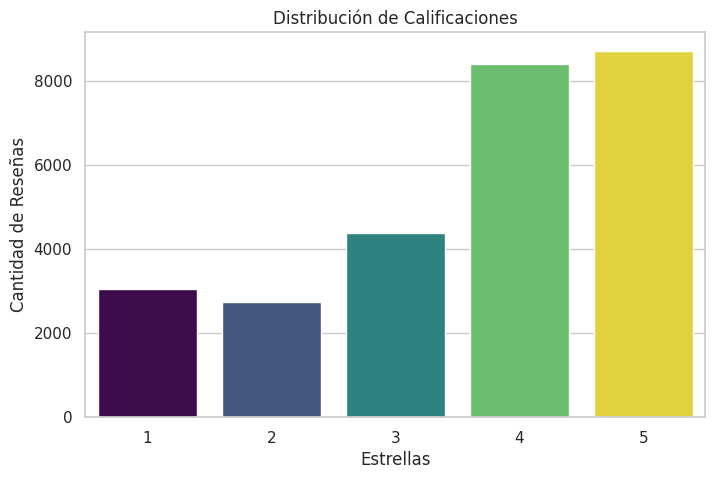

In [88]:

# 1. Distribución de calificaciones (estrellas)
plt.figure(figsize=(8,5))
sns.countplot(x='stars', data=df, hue='stars', palette='viridis', legend=False)
plt.title('Distribución de Calificaciones')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de Reseñas')
plt.show()



Eje X (horizontal): número de estrellas asignadas por los usuarios (de 1 a 5).

Eje Y (vertical): cantidad de reseñas que recibieron esa calificación.

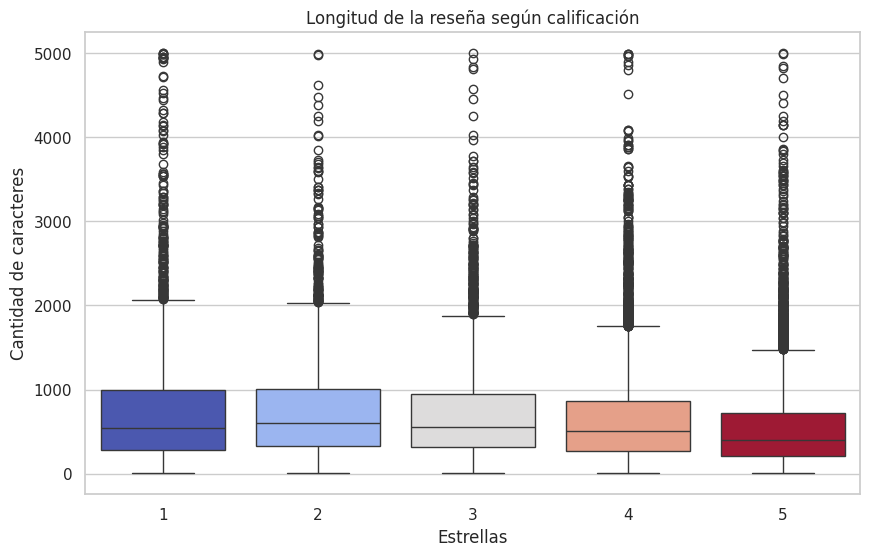

In [89]:

# 2. Longitud del texto vs estrellas
plt.figure(figsize=(10,6))
sns.boxplot(x='stars', y='text_length', data=df, hue='stars', palette='coolwarm', dodge=False, legend=False)
plt.title('Longitud de la reseña según calificación')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de caracteres')
plt.show()


#### 🔍 **Análisis:**
- Las reseñas con 1 y 2 estrellas parecen ser un poco más cortas en promedio.

- Las reseñas con 4 y 5 estrellas son un poco más largas, aunque hay algunos outliers (reseñas muy largas).

- Las longitudes son bastante consistentes entre las diferentes calificaciones, pero las reseñas más largas corresponden principalmente a 4 y 5 estrellas.

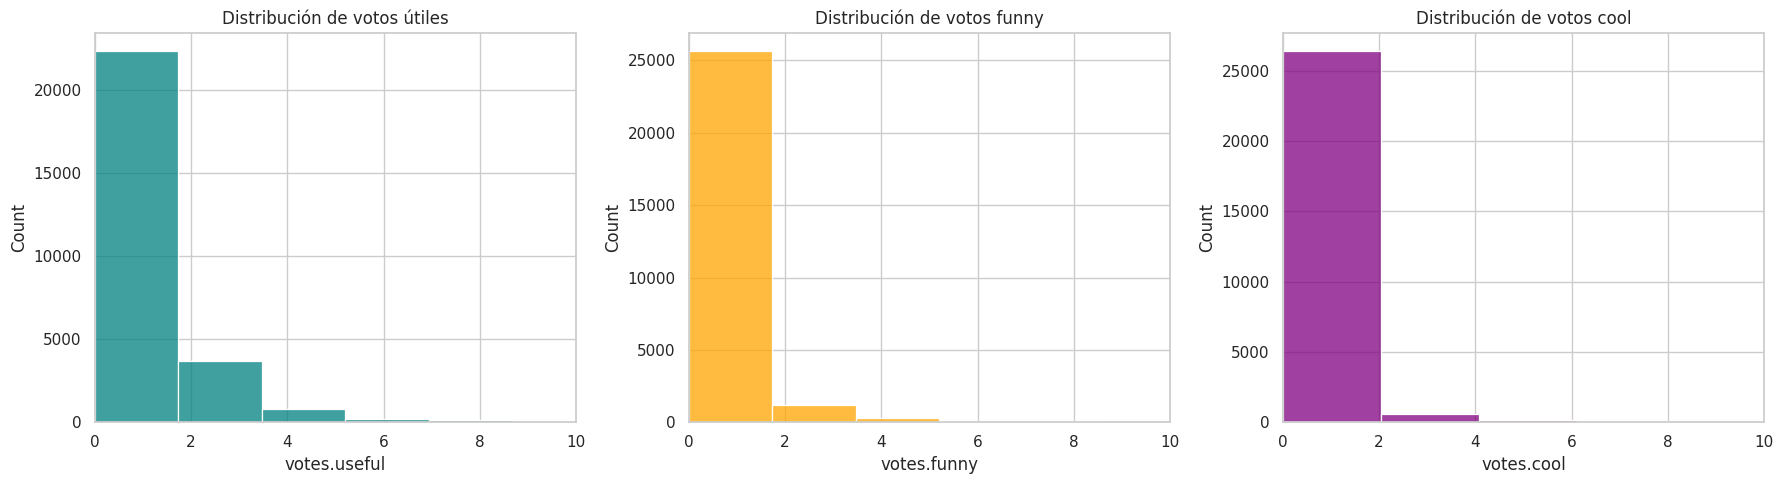

In [90]:

# 3. Distribución de votos útiles, funny y cool
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['votes.useful'], bins=30, kde=False, ax=axes[0], color='teal')
axes[0].set_title("Distribución de votos útiles")
axes[0].set_xlim(0, 10)

sns.histplot(df['votes.funny'], bins=30, kde=False, ax=axes[1], color='orange')
axes[1].set_title("Distribución de votos funny")
axes[1].set_xlim(0, 10)

sns.histplot(df['votes.cool'], bins=30, kde=False, ax=axes[2], color='purple')
axes[2].set_title("Distribución de votos cool")
axes[2].set_xlim(0, 10)

plt.tight_layout()
plt.show()


### 🎯 **Votos Útiles (`votes.useful`)**

En el gráfico de la izquierda, el valor **6** en el eje X significa que **6 personas consideraron que la reseña de un usuario fue útil** y votaron en consecuencia, dándole "votos útiles" a esa reseña.

Así, cada reseña puede recibir varios votos de usuarios que estén de acuerdo con lo útil, divertido o genial que encuentran esa reseña. La reseña en particular que tiene **6 votos útiles** recibió esa cantidad de votos de diferentes usuarios que la consideraron útil.

#### Ejemplo:
- Un usuario escribe una reseña sobre un restaurante.
- Esa reseña recibe **6 votos de otros usuarios** que consideran que la reseña les fue útil.

#### Resumen:
- **`votes.useful`** indica la cantidad de usuarios que consideran útil una reseña.

En ese gráfico, la mayoría de las reseñas **no tienen muchos votos útiles**, pero algunas pueden tener varios, como en el caso de la reseña que tiene **6 votos útiles**.

---

### 😂 **Votos Divertidos (`votes.funny`)**

- La **mayoría de las reseñas** no reciben votos en esta categoría.
- **La gran mayoría de las reseñas** tiene **0 votos divertidos**.
- **Pocas reseñas** recibieron **1 o 2 votos** en esta categoría.

---

### 😎 **Votos Geniales (`votes.cool`)**

- Similar a los votos divertidos, **la mayoría de las reseñas** no tienen votos en esta categoría.
- **La mayoría** tiene **0 votos geniales**.
- Unas **pocas reseñas** tienen **1 o 2 votos** en esta categoría.

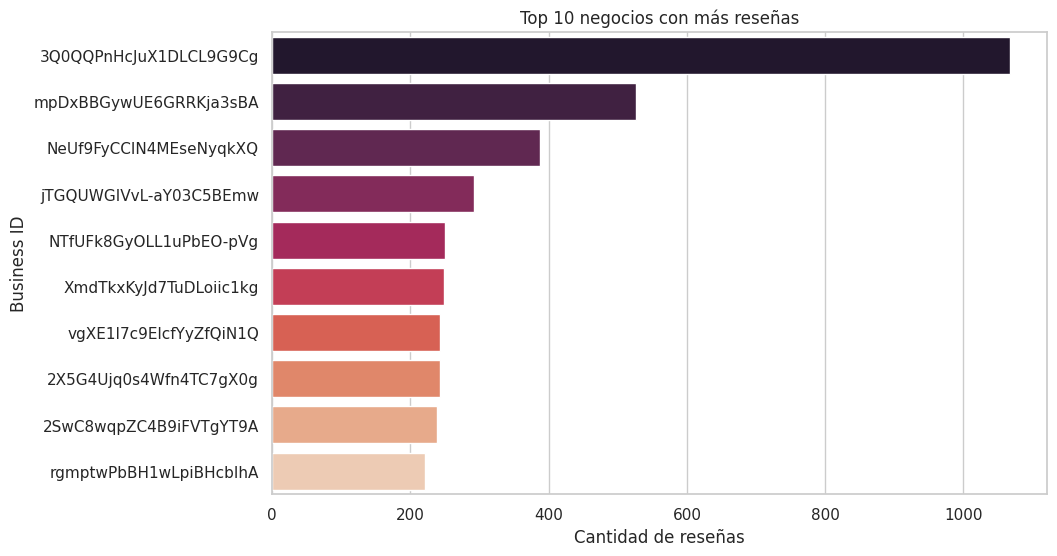

In [91]:

# 4. Top 10 negocios con más reseñas
top_businesses = df['business_id'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_businesses.values, y=top_businesses.index, hue=top_businesses.index, palette='rocket', legend=False)
plt.title("Top 10 negocios con más reseñas")
plt.xlabel("Cantidad de reseñas")
plt.ylabel("Business ID")
plt.show()



### 📊 Análisis del Gráfico: Top 10 Negocios con Más Reseñas

Este gráfico muestra los **Top 10 negocios con más reseñas** en el dataset de Yelp.

#### Ejes del Gráfico:
- **Eje Y**: Representa los **IDs de los negocios**. Estos identificadores son códigos únicos asignados a cada negocio por Yelp. Los IDs son cadenas largas y aleatorias, como por ejemplo:
  - `3QQQPnHcJxX1DLC9G9Cg`
  - `mpDxBBGywUE6GRRKja3sBA`
  - `NeUf9FyCCIN4MeseNyqKXQ`
  
  Estos **IDs** no son nombres de negocios visibles; son identificadores internos que Yelp utiliza para manejar sus datos de forma eficiente.

- **Eje X**: Muestra la **cantidad de reseñas** asociadas a cada negocio. El negocio con más reseñas es el que tiene el valor más alto en el eje X.

#### 🧐 Análisis:
- El **negocio con el ID `3QQQPnHcJxX1DLC9G9Cg`** tiene la mayor cantidad de reseñas (más de 900).
- Otros negocios con menos reseñas incluyen aquellos con los IDs **`mpDxBBGywUE6GRRKja3sBA`** y **`NeUf9FyCCIN4MeseNyqKXQ`**.

#### 🧠 ¿Por qué esos IDs largos y raros?
- Los **IDs de negocio** en Yelp son generados de manera aleatoria y única para cada negocio. No reflejan los nombres de los negocios directamente, por lo que los identificadores pueden parecer aleatorios y no legibles.

#### 🔎 ¿Qué hacer con estos IDs?
- S aber qué negocios corresponden a esos IDs, necesito buscar esos **IDs en la base de datos de Yelp** o combinar estos IDs con otros datos para obtener más contexto sobre qué negocio representa cada uno.



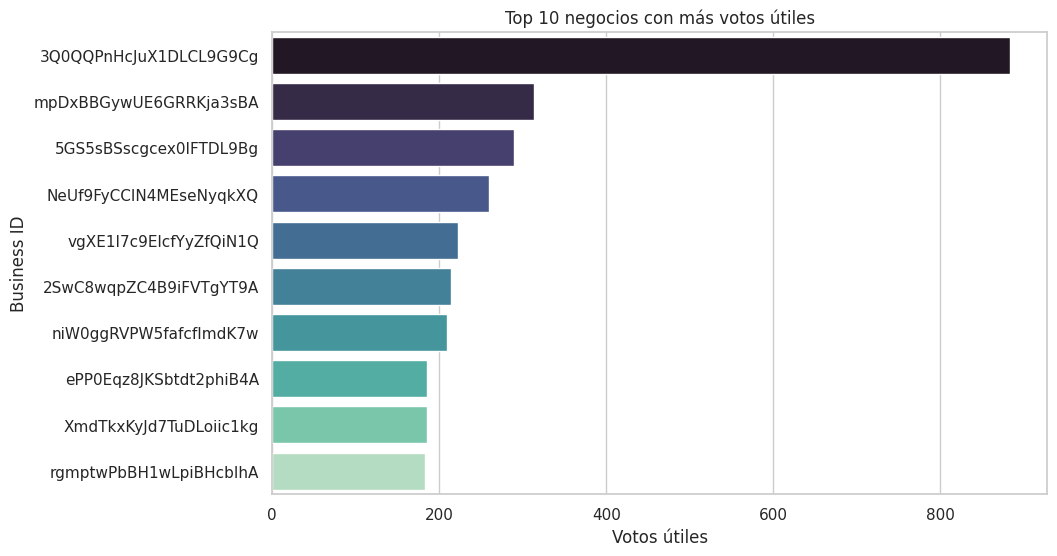

In [92]:
# 5. Top 10 negocios con más votos útiles
useful_votes_by_business = df.groupby('business_id')['votes.useful'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=useful_votes_by_business.values, y=useful_votes_by_business.index, hue=useful_votes_by_business.index, palette='mako', legend=False)
plt.title("Top 10 negocios con más votos útiles")
plt.xlabel("Votos útiles")
plt.ylabel("Business ID")
plt.show()

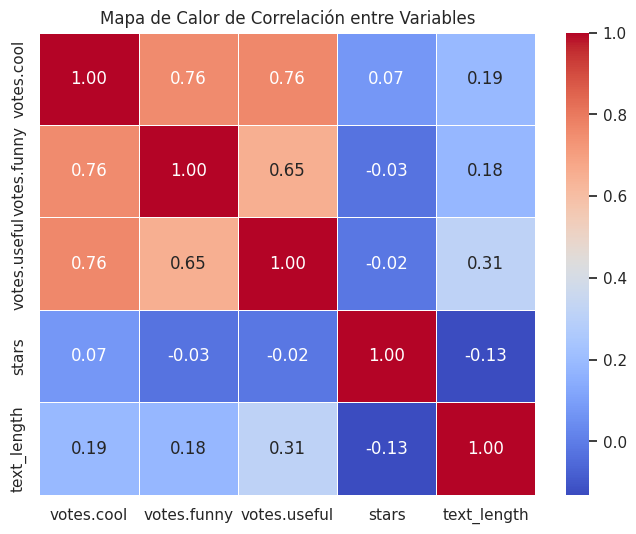

In [93]:

# Seleccionar las columnas numéricas para el análisis de correlación
numeric_cols = ['votes.cool', 'votes.funny', 'votes.useful', 'stars', 'text_length']

# Calcular la matriz de correlación
corr_matrix = df[numeric_cols].corr()

# Mostrar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Mapa de Calor de Correlación entre Variables")
plt.show()

#### Análisis de Correlación 🔍

- **`votes.useful`, `votes.funny`, y `votes.cool`** están **fuertemente correlacionados** entre sí. 🤝
- **`stars`** no tiene una fuerte correlación con estos votos o la longitud de las reseñas. ⭐❌
- Las **reseñas más largas** tienden a recibir más **votos útiles**, pero **no necesariamente calificaciones más altas**. 📝👍


-----

## Usos de NLP en el Dataset de Yelp

1. **Análisis de Sentimientos**: Evaluar el **sentimiento** (positivo, negativo, neutral) en las reseñas y su relación con las **calificaciones**.
2. **Extracción de Entidades**: Identificar **negocios**, **ubicaciones** y otros elementos clave en las reseñas usando técnicas de **NER**.
3. **Resumen Automático**: Crear **resúmenes breves** de reseñas largas usando **técnicas de resumen automático**.
4. **Topic Modeling**: Identificar **temas recurrentes** en las reseñas (por ejemplo, calidad de comida, servicio, etc.).
5. **Clasificación de Reseñas**: Predecir la **puntuación** de una reseña automáticamente a partir del texto.
6. **Extracción de Palabras Clave**: Detectar las **palabras más relevantes** en las reseñas mediante **TF-IDF**.
7. **Detección de Lenguaje**: **Segmentar reseñas** por idioma para análisis específico.
8. **Análisis Temporal**: Estudiar cómo cambian las **calificaciones** y **sentimientos** de las reseñas a lo largo del tiempo.

Estas son algunas formas de aplicar técnicas de **NLP** para extraer valor de las reseñas en el dataset de Yelp.


In [94]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable


Como las reseñas están en ingles , podemos usar textblob! 

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 text  \
0                                                                                                                                                                                                                                                               Mr Hoagie is an institution. Wa

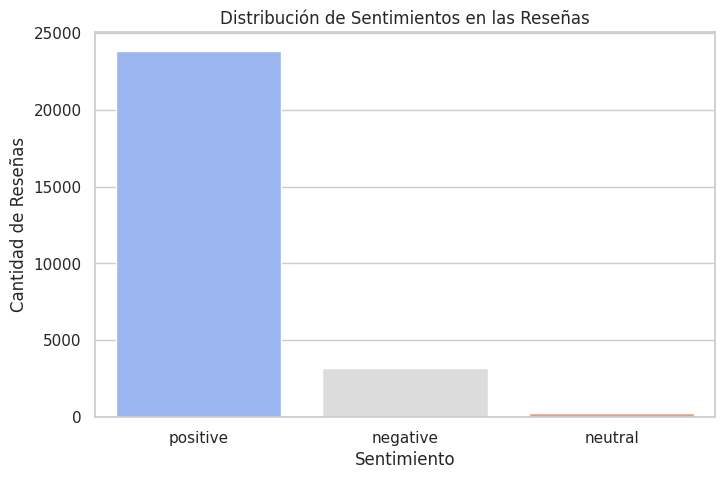

In [95]:
# Función para obtener la polaridad del sentimiento (valores entre -1 y 1)
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

# Aplicar la función a la columna 'text' para obtener la polaridad de cada reseña
df['sentiment'] = df['text'].apply(get_sentiment)

# Clasificar las reseñas en positivas, negativas y neutrales
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

# Mostrar los primeros resultados
print(df[['text', 'sentiment', 'sentiment_label']].head())


plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_label', data=df, hue='sentiment_label', palette='coolwarm', legend=False)
plt.title("Distribución de Sentimientos en las Reseñas")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de Reseñas")
plt.show()


In [96]:
# Mostrar 5 reseñas de cada clase de sentimiento (positivo, negativo, neutral)
positive_reviews = df[df['sentiment_label'] == 'positive'].head(5)
negative_reviews = df[df['sentiment_label'] == 'negative'].head(5)
neutral_reviews = df[df['sentiment_label'] == 'neutral'].head(5)

# Concatenar las reseñas para una visualización más clara
reviews_to_check = pd.concat([positive_reviews[['text', 'sentiment_label']],
                              negative_reviews[['text', 'sentiment_label']],
                              neutral_reviews[['text', 'sentiment_label']]])

# Ajustar pandas para no truncar el texto
pd.set_option('display.max_colwidth', None)

# Mostrar las reseñas completas
print(reviews_to_check)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            text  \
0                                                                                                                                                                                                                                                                   

##  👀 Observación de TextBlob:

**Reseña (203)**:  
"Take it from me; avoid this place at all cost. The only time I go is when I am starved and don't have the energy to cook or get edible food. And then after I have been kicking myself."

*"Créeme, evita este lugar a toda costa. Solo voy cuando tengo hambre y no tengo energía para cocinar ni para comer. Y después de haberme dado una paliza."*

- **Clasificación de TextBlob**: Neutral
- **Análisis**:  
  **TextBlob** clasificó esta reseña como **neutral**, pero claramente es una reseña **negativa**. El tono de la reseña es de descontento, con frases como "avoid this place at all cost" y "I've been kicking myself", lo cual indica una experiencia negativa. Esto sugiere que **TextBlob** no tomo correctamente el sentimiento intenso negativo de la reseña.


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 text  \
0                                                                                                                                                                                                                                                               Mr Hoagie is an institution. Wa

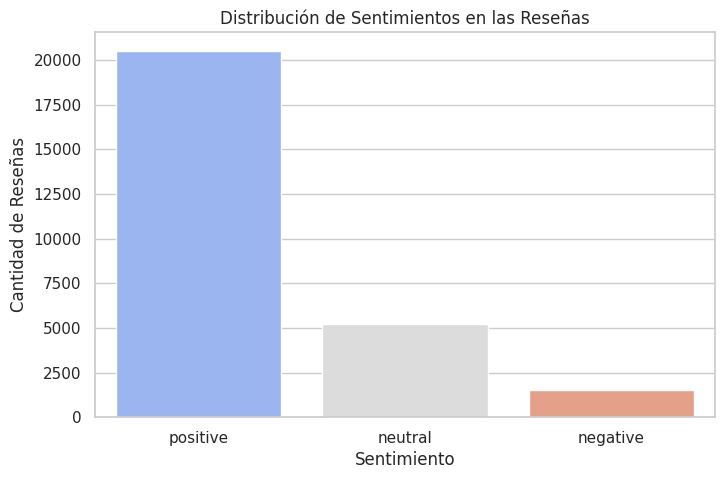

In [97]:
# Función para obtener la polaridad del sentimiento (valores entre -1 y 1)
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

# Aplicar la función a la columna 'text' para obtener la polaridad de cada reseña
df['sentiment'] = df['text'].apply(get_sentiment)

# Clasificar las reseñas en positivas, negativas y neutrales
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral'))

# Mostrar los primeros resultados
print(df[['text', 'sentiment', 'sentiment_label']].head())


plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_label', data=df, hue='sentiment_label', palette='coolwarm', legend=False)
plt.title("Distribución de Sentimientos en las Reseñas")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de Reseñas")
plt.show()

In [98]:
# Filtrar la reseña con el índice 203
review_203 = df[df.index == 203][['text', 'sentiment_label']]

# Mostrar la reseña y su clasificación
print(review_203)


                                                                                                                                                                                          text  \
203  Take it from me; avoid this place at all cost.  The only time I go is when I am starved and don't have the energy to cook or get edible food.  And then after I have been kicking myself.   

    sentiment_label  
203         neutral  


❌ ERROR!!! Para mejorar la precisión de la clasificación de sentimientos, se debe probar con un modelo más avanzado, al cambiar la reseña 203 por la palabra unica "awful" se observa que recien ahi toma la reseñal como negativa, se entiende que el cierto orden utilizado en esa reseña o su expresion le cuesta al algoritmo determinar correctamente el sentimiento.



## 📌 Extracción de Entidades Nombradas (NER) con spaCy

Se aplicó **spaCy** para extraer entidades nombradas en cada reseña del dataset. El modelo utilizado fue `en_core_web_sm`, que permite identificar personas, organizaciones, fechas, ubicaciones y más.



In [99]:
# Función para extraer entidades nombradas de un texto
def extract_entities(text):
    doc = nlp(text)
    # Obtenemos las entidades como tuplas (texto, etiqueta)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Aplicamos la función a cada reseña del DataFrame
df['named_entities'] = df['text'].apply(extract_entities)

# Mostrar algunos ejemplos con sus entidades extraídas
print(df[['text', 'named_entities']].head(5))


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 text  \
0                                                                                                                                                                                                                                                               Mr Hoagie is an institution. Wa




### 🧠 ¿Qué representa cada resultado?

Cada fila contiene una lista de **tuplas (entidad, etiqueta)** detectadas por spaCy. Por ejemplo:

```python
[(Hoagie, ORG), (30 years ago, DATE), (70s, DATE), (Italian, NORP), (Subway, ORG)]
```

Esto significa:
- `"Hoagie"` fue identificado como una organización (`ORG`)
- `"30 years ago"` y `"70s"` como fechas (`DATE`)
- `"Italian"` como una nacionalidad o grupo cultural (`NORP`)
- `"Subway"` como organización (`ORG`)



### ✅ Observaciones por reseña

| Reseña | Entidades destacadas | Comentario |
|--------|-----------------------|------------|
| 0      | `Subway`, `30 years ago`, `Italian` | Buen reconocimiento general. |
| 1      | `Superb` (`PERSON`) | Falso positivo. |
| 2      | `the weekend`, `daily` | Reconoce expresiones temporales. |
| 3      | `Monday`, `Wednesday night`, `$0.75` | Reconocimiento correcto de fechas y dinero. |
| 4      | `Cajun` (`LOC`) | Interpretación discutible según el contexto. |





### 📝 Conclusiones sobre Tópicos y Keywords por Negocio (Yelp Reviews)

Este análisis se enfocó en identificar automáticamente **tópicos temáticos dominantes** y sus **palabras clave (keywords)** para cada negocio (`business_id`) en el dataset de reseñas de Yelp, utilizando **TF-IDF** y **NMF (Non-negative Matrix Factorization)**.



#### 🔍 Pasos:

- Agrupamos todas las reseñas por negocio.
- Aplicamos **TF-IDF** para convertir los textos en vectores numéricos que representan la importancia de las palabras.
- Utilizamos **NMF** para descubrir 5 tópicos latentes en las reseñas.
- Asignamos a cada negocio un **tópico dominante** y las **palabras clave** más representativas de ese tema.


In [100]:
# Agrupar las reseñas por negocio
grouped_reviews = df.groupby("business_id")["text"].apply(lambda texts: " ".join(texts)).reset_index()

# Crear la matriz TF-IDF (sólo palabras en inglés, eliminar stopwords)
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(grouped_reviews["text"])

# Aplicar NMF para extraer tópicos (cambiá n_components si querés más tópicos)
nmf_model = NMF(n_components=5, random_state=42)
nmf_features = nmf_model.fit_transform(tfidf_matrix)

# Obtener palabras clave (keywords) más relevantes por tópico
feature_names = tfidf_vectorizer.get_feature_names_out()
top_keywords_per_topic = []
for topic_idx, topic in enumerate(nmf_model.components_):
    top_keywords = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    top_keywords_per_topic.append(top_keywords)

# Asignar el tópico dominante y sus keywords a cada negocio
grouped_reviews["dominant_topic"] = np.argmax(nmf_features, axis=1)
grouped_reviews["keywords"] = grouped_reviews["dominant_topic"].apply(lambda idx: top_keywords_per_topic[idx])

# Mostrar resultados
print(grouped_reviews[["business_id", "dominant_topic", "keywords"]].head())

              business_id  dominant_topic  \
0  --UE_y6auTgq3FXlvUMkbw               0   
1  -1t3U6osBvqFLHseoCxiIA               1   
2  -6JY1T0w4XETux5kGOj84g               0   
3  -Am2JVkb7nwvBAUwSugG0A               0   
4  -FQL3Q-Prwxp577SFr5MfA               1   

                                                                     keywords  
0  [food, good, place, chicken, restaurant, bar, great, lunch, service, like]  
1           [store, just, place, like, time, great, shop, ve, selection, don]  
2  [food, good, place, chicken, restaurant, bar, great, lunch, service, like]  
3  [food, good, place, chicken, restaurant, bar, great, lunch, service, like]  
4           [store, just, place, like, time, great, shop, ve, selection, don]  



#### ✅ Hallazgos principales

- Muchos negocios comparten tópicos relacionados con:
  - Experiencias generales de **comida y servicio** (keywords: `food`, `good`, `place`, `service`, `chicken`, `restaurant`).
  - **Compras y tiendas** (keywords: `store`, `shop`, `selection`, `great`, `just`, `time`, `like`).
- Se observó una clara diferenciación entre negocios de gastronomía y comercios minoristas basada en los tópicos extraídos.
- Estas agrupaciones permiten una primera segmentación temática de los negocios sin necesidad de etiquetas manuales.

---

#### 🧠 ¿Para qué puede usarse esto?

- Para clasificar negocios automáticamente según el contenido de sus reseñas.
- Para detectar temas recurrentes en las opiniones de los usuarios.
- Para enriquecer análisis de sentimiento con contexto temático.
- Para generar filtros de búsqueda o recomendaciones basadas en intereses (por tópico).

---

#### 💾 Resultado

Cada negocio (`business_id`) ahora cuenta con:
- Un número de tópico dominante (`dominant_topic`)
- Una lista de palabras clave asociadas (`keywords`)

Estos datos están listos para ser utilizados en análisis adicionales, visualizaciones o sistemas de recomendación.

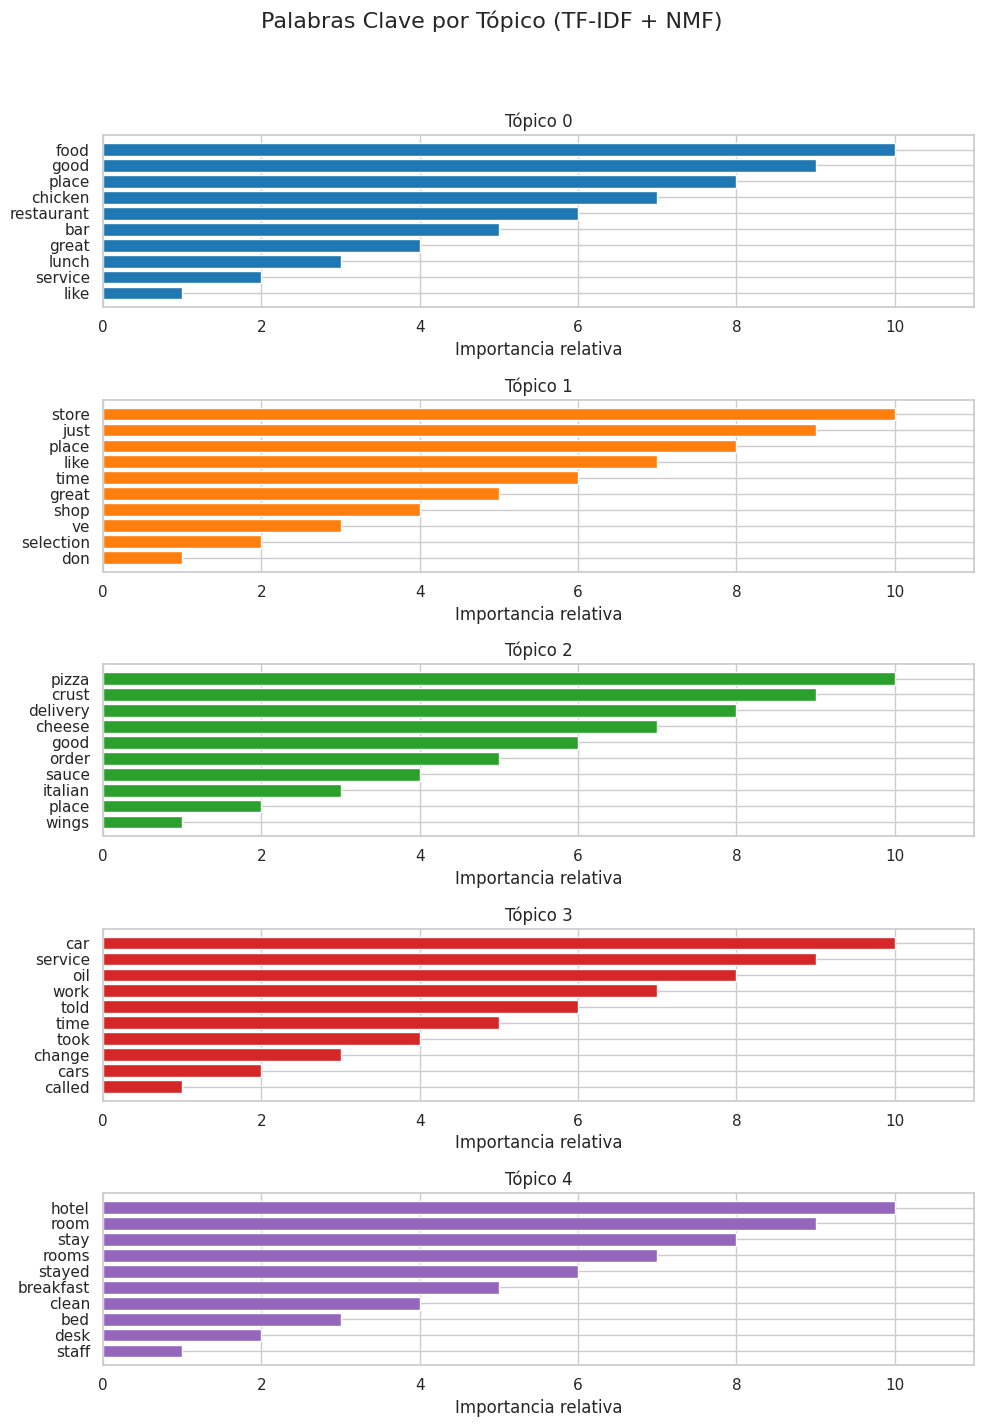

In [101]:
import matplotlib.pyplot as plt

# Número de tópicos definidos en el modelo NMF
n_topics = len(top_keywords_per_topic)

# Configurar la grilla de subplots
fig, axes = plt.subplots(n_topics, 1, figsize=(10, n_topics * 3))
fig.suptitle("Palabras Clave por Tópico (TF-IDF + NMF)", fontsize=16)

# Dibujar cada tópico en un subplot separado
for i, ax in enumerate(axes):
    words = top_keywords_per_topic[i]
    ax.barh(words[::-1], range(1, len(words)+1), color=plt.cm.tab10(i))
    ax.set_title(f"Tópico {i}")
    ax.set_xlabel("Importancia relativa")
    ax.set_xlim(0, 11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 🧠 ¿Qué son los Tópicos en NLP?

En el contexto de análisis de texto, un **tópico** representa un conjunto de palabras que tienden a aparecer juntas con frecuencia en los documentos, indicando un **tema latente** que no está explícitamente definido. Para detectarlos, utilizamos un modelo de **NMF (Non-negative Matrix Factorization)** sobre una matriz TF-IDF generada a partir de las reseñas agrupadas por `business_id`.

---

## 🧵 Interpretación de los Tópicos Detectados

A continuación se detallan los 5 tópicos principales detectados y una interpretación tentativa basada en sus palabras clave más representativas:

| Tópico | Palabras clave                                        | Tema probable                             |
|--------|--------------------------------------------------------|-------------------------------------------|
| 0      | food, good, place, chicken, restaurant, bar            | Restaurantes y comida                     |
| 1      | store, place, time, shop, selection                    | Experiencia de compra en tiendas          |
| 2      | pizza, crust, delivery, cheese, sauce                  | Comida rápida y delivery (principalmente pizza) |
| 3      | car, oil, service, work, told                          | Talleres y servicios automotrices         |
| 4      | hotel, room, stay, breakfast, staff                    | Hoteles y experiencia de alojamiento       |

---

## ✅ Conclusiones

- Los tópicos detectados reflejan de manera clara los **diferentes sectores de negocios** que los usuarios reseñan en Yelp: comida, hoteles, mecánica, etc.
- Esta técnica permite **agrupar reseñas similares** sin conocer de antemano su contenido, lo cual es muy útil para tareas de:
  - Clasificación automática de negocios.
  - Resumen temático de grandes volúmenes de texto.
  - Segmentación de mercado.
- Además, si combinamos estos tópicos con análisis de **sentimientos**, podríamos descubrir, por ejemplo, **qué tipo de servicios generan más opiniones negativas o positivas**, o **qué temas generan más engagement**.

Este enfoque permite una **vista general muy valiosa para negocios o analistas** que deseen detectar oportunidades, debilidades o simplemente entender mejor las opiniones de sus usuarios.


In [102]:
# Contar cantidad de reseñas positivas y negativas por negocio
positive_counts = df[df['sentiment_label'] == 'positive'].groupby('business_id').size()
negative_counts = df[df['sentiment_label'] == 'negative'].groupby('business_id').size()

# Obtener el negocio con más reseñas positivas
top_positive_business = positive_counts.idxmax()
top_positive_count = positive_counts.max()

# Obtener el negocio con más reseñas negativas
top_negative_business = negative_counts.idxmax()
top_negative_count = negative_counts.max()

print(f"📈 Negocio con MÁS comentarios POSITIVOS:\n- ID: {top_positive_business}\n- Cantidad: {top_positive_count}")

print(f"\n📉 Negocio con MÁS comentarios NEGATIVOS:\n- ID: {top_negative_business}\n- Cantidad: {top_negative_count}")


📈 Negocio con MÁS comentarios POSITIVOS:
- ID: 3Q0QQPnHcJuX1DLCL9G9Cg
- Cantidad: 741

📉 Negocio con MÁS comentarios NEGATIVOS:
- ID: 3Q0QQPnHcJuX1DLCL9G9Cg
- Cantidad: 61


## 🧾 Conclusiones Finales



🔍 **Resumen de hallazgos:**

- Se identificaron patrones de calificaciones y sentimientos predominantes, mostrando una tendencia positiva general en la mayoría de las reseñas.
- Se aplicó análisis de sentimientos con **TextBlob**  para clasificar las reseñas en positivas, negativas o neutrales.
- Se extrajeron entidades nombradas con **spaCy** y se detectaron palabras clave y tópicos por negocio usando **TF-IDF + NMF**, lo que permitió comprender los temas más discutidos.
- También se generaron visualizaciones que permitieron descubrir las palabras más frecuentes y representativas en los textos.

📊 **Negocio más destacado**:

Curiosamente, **el mismo negocio** aparece como el que más comentarios positivos y negativos recibe, lo cual puede indicar que:
- Es un negocio muy popular con alto volumen de interacción.
- Genera opiniones polarizadas en los usuarios.

| Tipo de sentimiento | Business ID                    | Cantidad de reseñas |
|---------------------|--------------------------------|----------------------|
| ✅ Positivas         | `3Q0QQPnHcJuX1DLCL9G9Cg`       | 741                  |
| ❌ Negativas         | `3Q0QQPnHcJuX1DLCL9G9Cg`       | 61                   |

Este análisis no sólo permitió entender el comportamiento de los usuarios, sino también detectar tendencias, temas recurrentes y oportunidades para futuras mejoras en los servicios ofrecidos por los negocios.

🚀 **Siguientes pasos posibles**:
- Entrenar un modelo propio de clasificación de sentimientos para mejorar precisión.
- Combinar reseñas con metadatos (ubicación, tipo de negocio, etc.).
- Realizar análisis temporal para observar evolución de calificaciones a lo largo del tiempo.


